# Bank Customer Churn Prediction

Identify customers likely to leave Beta Bank and meet the project requirement of test F1 ≥ 0.59.

This public edition preserves the analysis in Portuguese. See the English README and VALIDATION.md for results, publication edits and reproduction limits.


In [ ]:
from pathlib import Path

# Resolve the same data directory from the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
if not DATA_DIR.is_dir():
    raise FileNotFoundError("Open this notebook from the repository root or notebooks/ and follow data/README.md.")




Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>





## Objetivo

Os clientes do **Beta Bank** estão saindo pouco a pouco todo mês. Os banqueiros descobriram que é mais barato manter os clientes existentes do que atrair novos.

O objetivo deste projeto é **prever se um cliente vai deixar o banco em breve**, com base em dados históricos de comportamento.

O principal critério de sucesso é atingir um **F1-score mínimo de 0,59** no conjunto de teste. Além disso, a métrica **AUC-ROC** será medida e comparada com o F1-score.

### Variável alvo
- `Exited`: 1 = cliente saiu; 0 = cliente permaneceu

### Etapas
1. Carregamento e preparação dos dados
2. Análise exploratória e equilíbrio das classes
3. Modelagem sem correção de desequilíbrio (baseline)
4. Melhoria com técnicas de balanceamento
5. Teste final e conclusões

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.utils import shuffle

## 1. Carregamento e Inspeção Inicial dos Dados

Vou carregar o conjunto de dados e realizar uma inspeção inicial, verificando:
- Número de linhas e colunas;
- Presença de valores ausentes;
- Duplicatas;
- Tipos de dados de cada coluna.

In [ ]:
data = pd.read_csv(DATA_DIR / 'Churn.csv')

print(data.head())
print()
print(data.info())
print()
print(data.describe())
print()
print('Valores ausentes por coluna:')
print(data.isnull().sum())
print()
print('Duplicatas:', data.duplicated().sum())

## 2. Conclusões da Análise Inicial

A partir da inspeção inicial, observei que:

- O conjunto possui **10.000 registros e 14 colunas**;
- Há **valores ausentes em `Tenure`** — serão preenchidos com a mediana do conjunto de treinamento;
- Não há registros duplicados;
- As colunas `RowNumber`, `CustomerId` e `Surname` são **identificadores sem valor preditivo** e serão removidas;
- As colunas `Geography` e `Gender` são **categóricas** e precisam de codificação OHE;
- As demais colunas são numéricas e serão padronizadas com `StandardScaler`.

Abaixo, visualizo a distribuição das variáveis numéricas e da variável-alvo para entender melhor o comportamento dos dados.

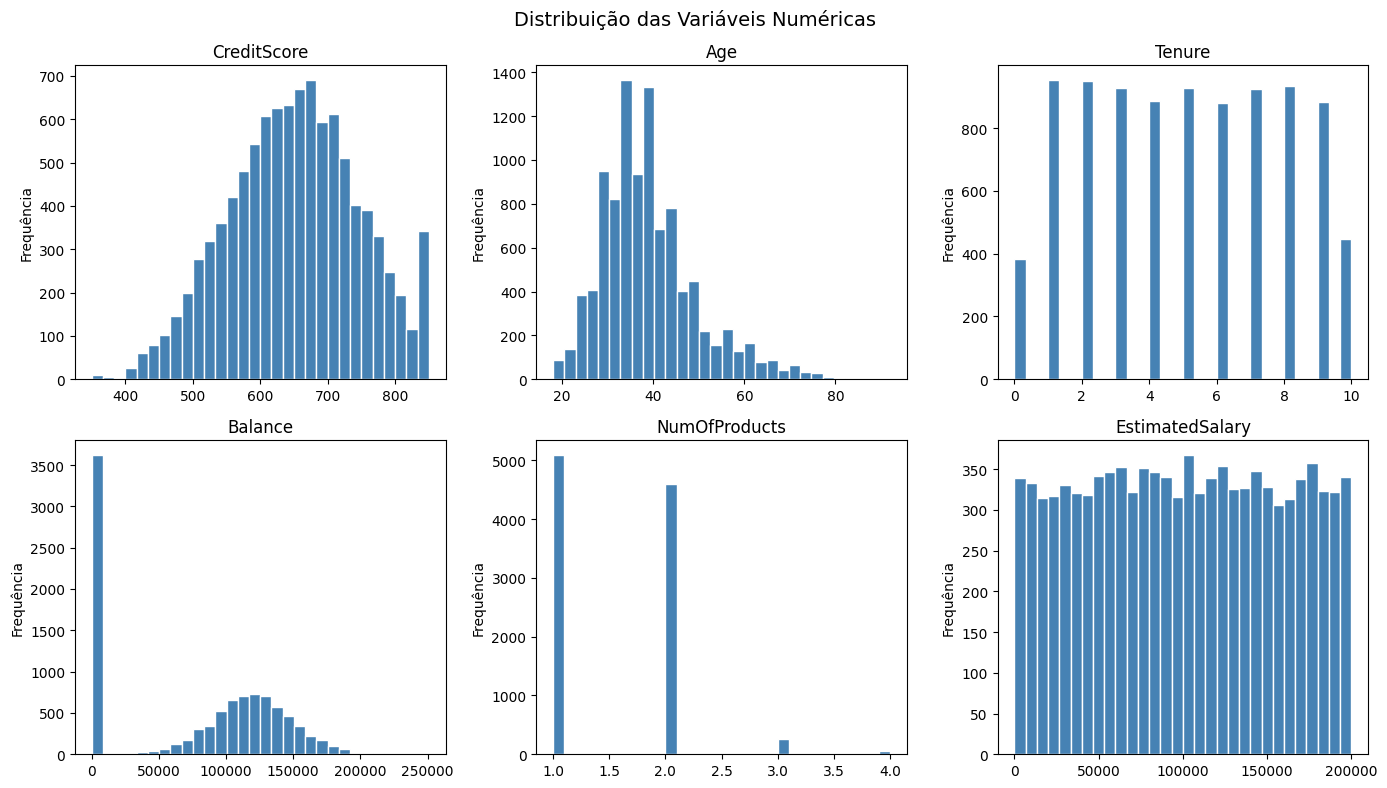

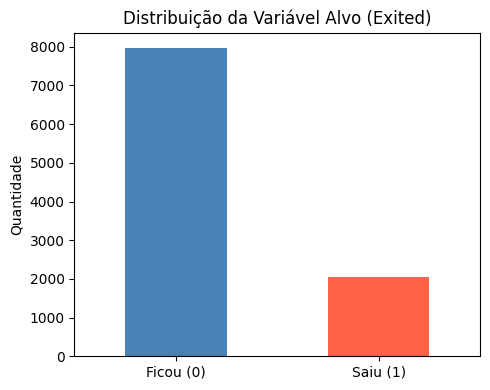

Distribuição relativa da variável alvo:
0    0.796
1    0.204
Name: Exited, dtype: float64


In [3]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=14)

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(data[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
data['Exited'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Distribuição da Variável Alvo (Exited)')
ax.set_xticklabels(['Ficou (0)', 'Saiu (1)'], rotation=0)
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.show()

print('Distribuição relativa da variável alvo:')
print(data['Exited'].value_counts(normalize=True).round(3))

## 3. Pré-processamento dos Dados

Com base nas conclusões acima, realizo as seguintes etapas de pré-processamento:

1. **Remoção de colunas irrelevantes**: `RowNumber`, `CustomerId` e `Surname` não contribuem para a previsão;
2. **Codificação OHE**: `Geography` e `Gender` são convertidas em variáveis binárias com `drop_first=True` para evitar a armadilha das dummies;
3. **Divisão dos dados**: 60% treino / 20% validação / 20% teste — a divisão ocorre antes do tratamento de ausentes e padronização;
4. **Tratamento de valores ausentes**: `Tenure` recebe a mediana do conjunto de treinamento;
5. **Padronização**: `StandardScaler` é ajustado apenas no treino e aplicado nos demais conjuntos.

In [4]:
# 1. Remover colunas irrelevantes
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 2. Codificação OHE
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True)

# 3. Separar alvo e características
target   = data['Exited']
features = data.drop('Exited', axis=1)

# 4. Divisão: treino (60%), validação (20%), teste (20%)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=12345
)
features_train, features_valid, target_train, target_valid = train_test_split(
    features_train, target_train, test_size=0.25, random_state=12345
)

print('Tamanhos dos conjuntos:')
print(f'  Treino:    {features_train.shape}')
print(f'  Validação: {features_valid.shape}')
print(f'  Teste:     {features_test.shape}')

# 5. Tratar ausentes em Tenure com mediana do treino
tenure_median = features_train['Tenure'].median()
features_train['Tenure'] = features_train['Tenure'].fillna(tenure_median)
features_valid['Tenure'] = features_valid['Tenure'].fillna(tenure_median)
features_test['Tenure']  = features_test['Tenure'].fillna(tenure_median)

# 6. Padronização das características numéricas
numeric = ['CreditScore', 'Age', 'Tenure', 'Balance',
           'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

scaler = StandardScaler()
scaler.fit(features_train[numeric])
features_train[numeric] = scaler.transform(features_train[numeric])
features_valid[numeric] = scaler.transform(features_valid[numeric])
features_test[numeric]  = scaler.transform(features_test[numeric])

print('\nPré-processamento concluído.')
print(features_train.head())

Tamanhos dos conjuntos:
  Treino:    (6000, 11)
  Validação: (2000, 11)
  Teste:     (2000, 11)

Pré-processamento concluído.
      CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
492     -0.134048 -0.078068 -0.369113  0.076163       0.816929  -1.550255   
6655    -1.010798  0.494555 -0.007415  0.136391      -0.896909   0.645055   
4287     0.639554  1.353490 -1.454209  0.358435      -0.896909   0.645055   
42      -0.990168  2.116987 -1.092511  0.651725      -0.896909   0.645055   
8178     0.567351  0.685430  0.715982  0.813110       0.816929   0.645055   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
492         0.968496         0.331571                  0                0   
6655        0.968496        -0.727858                  0                0   
4287        0.968496        -0.477006                  1                0   
42          0.968496        -0.100232                  0                0   
8178        0.968496      

/tmp/ipykernel_32/2511705255.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_test['Tenure']  = features_test['Tenure'].fillna(tenure_median)
/tmp/ipykernel_32/2511705255.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_test[numeric]  = scaler.transform(features_test[numeric])
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1738: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

## 4. Equilíbrio das Classes

Antes de treinar qualquer modelo, é fundamental entender o equilíbrio entre as classes. Um dataset desbalanceado pode levar o modelo a prever sempre a classe majoritária, resultando em alta acurácia mas baixo F1-score para a classe de interesse (clientes que saíram).

In [5]:
class_freq = target_train.value_counts(normalize=True)
print('Frequência relativa das classes no treino:')
print(class_freq.round(3))
print(f'\nClasse 0 (ficou): {class_freq[0]:.1%}')
print(f'Classe 1 (saiu):  {class_freq[1]:.1%}')
print('\n→ Dataset DESBALANCEADO: ~80% permaneceu vs ~20% saiu.')
print('  Modelos sem correção tenderão a prever quase sempre a classe 0.')

Frequência relativa das classes no treino:
0    0.797
1    0.203
Name: Exited, dtype: float64

Classe 0 (ficou): 79.7%
Classe 1 (saiu):  20.3%

→ Dataset DESBALANCEADO: ~80% permaneceu vs ~20% saiu.
  Modelos sem correção tenderão a prever quase sempre a classe 0.


## 5. Modelo Sem Correção de Desequilíbrio (Baseline)

Treino um modelo de Floresta Aleatória sem qualquer técnica de balanceamento para estabelecer uma linha de base e confirmar o impacto do desequilíbrio no F1-score.

In [6]:
model_base = RandomForestClassifier(n_estimators=100, random_state=12345)
model_base.fit(features_train, target_train)
pred_base = model_base.predict(features_valid)

f1_base  = f1_score(target_valid, pred_base)
auc_base = roc_auc_score(target_valid, model_base.predict_proba(features_valid)[:, 1])

print('=== BASELINE (sem correção) ===')
print(f'F1-score : {f1_base:.4f}')
print(f'AUC-ROC  : {auc_base:.4f}')
print()
print(classification_report(target_valid, pred_base))
print('→ F1 abaixo de 0,59 — o modelo ignora boa parte dos clientes que saíram.')

=== BASELINE (sem correção) ===
F1-score : 0.5596
AUC-ROC  : 0.8445

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1609
           1       0.74      0.45      0.56       391

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

→ F1 abaixo de 0,59 — o modelo ignora boa parte dos clientes que saíram.


## 6. Melhoria do Modelo — Técnicas de Balanceamento

Utilizo três abordagens para corrigir o desequilíbrio de classes, varrendo diferentes combinações de hiperparâmetros (`n_estimators` e `max_depth`) em cada uma.

### Abordagem 1: `class_weight='balanced'`

O algoritmo penaliza mais os erros na classe minoritária, ponderando automaticamente os pesos inversamente proporcionais à frequência de cada classe. Não altera os dados — apenas o processo de aprendizado.

In [7]:
best_f1_cw    = 0
best_model_cw = None
best_params_cw = {}

for n_est in [100, 200]:
    for depth in [5, 10, 15, None]:
        m = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            class_weight='balanced',
            random_state=12345
        )
        m.fit(features_train, target_train)
        pred = m.predict(features_valid)
        f1   = f1_score(target_valid, pred)
        if f1 > best_f1_cw:
            best_f1_cw     = f1
            best_params_cw = {'n_estimators': n_est, 'max_depth': depth}
            best_model_cw  = m

print(f'Melhor F1 (class_weight): {best_f1_cw:.4f}')
print(f'Parâmetros: {best_params_cw}')

Melhor F1 (class_weight): 0.5917
Parâmetros: {'n_estimators': 200, 'max_depth': 10}


### Abordagem 2: Superamostragem (Upsampling)

Replico as observações da classe minoritária (Exited = 1) para equilibrar a proporção entre as classes. O embaralhamento final evita que o modelo aprenda padrões relacionados à ordem dos dados.

In [8]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones  = features[target == 1]
    target_zeros   = target[target == 0]
    target_ones    = target[target == 1]

    features_up = pd.concat([features_zeros] + [features_ones] * repeat)
    target_up   = pd.concat([target_zeros]   + [target_ones]   * repeat)

    features_up, target_up = shuffle(features_up, target_up, random_state=12345)
    return features_up, target_up

features_up, target_up = upsample(features_train, target_train, 4)

print('Distribuição após superamostragem:')
print(target_up.value_counts())

best_f1_up    = 0
best_model_up = None
best_params_up = {}

for n_est in [100, 200]:
    for depth in [5, 10, 15, None]:
        m = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            random_state=12345
        )
        m.fit(features_up, target_up)
        pred = m.predict(features_valid)
        f1   = f1_score(target_valid, pred)
        if f1 > best_f1_up:
            best_f1_up     = f1
            best_params_up = {'n_estimators': n_est, 'max_depth': depth}
            best_model_up  = m

print(f'\nMelhor F1 (upsampling): {best_f1_up:.4f}')
print(f'Parâmetros: {best_params_up}')

Distribuição após superamostragem:
1    4876
0    4781
Name: Exited, dtype: int64

Melhor F1 (upsampling): 0.5950
Parâmetros: {'n_estimators': 200, 'max_depth': 15}


### Abordagem 3: Subamostragem (Downsampling)

Reduzo a quantidade de observações da classe majoritária (Exited = 0) para equilibrar as classes. Embora perca informação, o método é eficiente e rápido para treinar.

In [9]:
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones  = features[target == 1]
    target_zeros   = target[target == 0]
    target_ones    = target[target == 1]

    features_zeros = features_zeros.sample(frac=fraction, random_state=12345)
    target_zeros   = target_zeros.sample(frac=fraction, random_state=12345)

    features_down = pd.concat([features_zeros, features_ones])
    target_down   = pd.concat([target_zeros,   target_ones])

    features_down, target_down = shuffle(features_down, target_down, random_state=12345)
    return features_down, target_down

features_down, target_down = downsample(features_train, target_train, 0.25)

print('Distribuição após subamostragem:')
print(target_down.value_counts())

best_f1_down    = 0
best_model_down = None
best_params_down = {}

for n_est in [100, 200]:
    for depth in [5, 10, 15, None]:
        m = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            random_state=12345
        )
        m.fit(features_down, target_down)
        pred = m.predict(features_valid)
        f1   = f1_score(target_valid, pred)
        if f1 > best_f1_down:
            best_f1_down     = f1
            best_params_down = {'n_estimators': n_est, 'max_depth': depth}
            best_model_down  = m

print(f'\nMelhor F1 (downsampling): {best_f1_down:.4f}')
print(f'Parâmetros: {best_params_down}')

Distribuição após subamostragem:
1    1219
0    1195
Name: Exited, dtype: int64

Melhor F1 (downsampling): 0.5653
Parâmetros: {'n_estimators': 100, 'max_depth': 10}


## 7. Comparação dos Modelos na Validação

Comparo o F1-score de todas as abordagens testadas para escolher o melhor modelo para o teste final.

=== RESUMO — F1-SCORE NA VALIDAÇÃO ===
  ✗ Baseline (sem correção)        F1 = 0.5596
  ✓ class_weight=balanced          F1 = 0.5917
  ✓ Superamostragem                F1 = 0.5950
  ✗ Subamostragem                  F1 = 0.5653


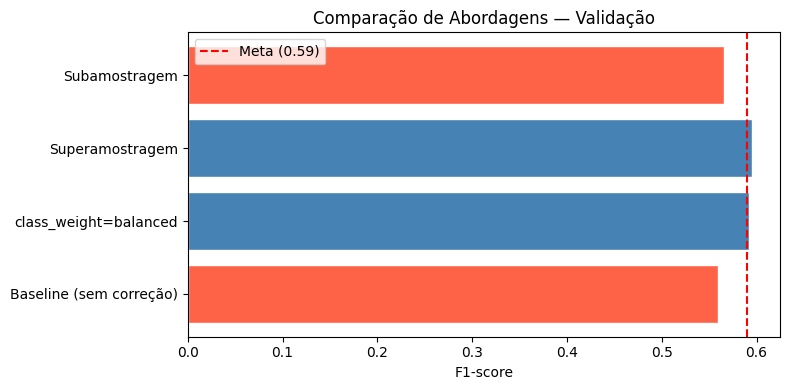

In [10]:
resultados = {
    'Baseline (sem correção)': f1_base,
    'class_weight=balanced':   best_f1_cw,
    'Superamostragem':         best_f1_up,
    'Subamostragem':           best_f1_down,
}

print('=== RESUMO — F1-SCORE NA VALIDAÇÃO ===')
for nome, f1 in resultados.items():
    status = '✓' if f1 >= 0.59 else '✗'
    print(f'  {status} {nome:<30} F1 = {f1:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
nomes = list(resultados.keys())
vals  = list(resultados.values())
cores = ['tomato' if v < 0.59 else 'steelblue' for v in vals]
ax.barh(nomes, vals, color=cores, edgecolor='white')
ax.axvline(0.59, color='red', linestyle='--', label='Meta (0.59)')
ax.set_xlabel('F1-score')
ax.set_title('Comparação de Abordagens — Validação')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Teste Final

Seleciono a abordagem com maior F1-score na validação e aplico no **conjunto de teste** — dados que o modelo nunca viu durante o desenvolvimento. Calculo F1-score e AUC-ROC.

In [11]:
candidatos = {
    'class_weight': (best_f1_cw,   best_model_cw),
    'upsampling':   (best_f1_up,   best_model_up),
    'downsampling': (best_f1_down, best_model_down),
}

best_name = max(candidatos, key=lambda k: candidatos[k][0])
best_f1_val, best_model_final = candidatos[best_name]
print(f'Melhor abordagem: {best_name} (F1 validação = {best_f1_val:.4f})')

pred_test = best_model_final.predict(features_test)
prob_test  = best_model_final.predict_proba(features_test)[:, 1]

f1_test  = f1_score(target_test, pred_test)
auc_test = roc_auc_score(target_test, prob_test)

print()
print('=== RESULTADO FINAL (TESTE) ===')
print(f'F1-score : {f1_test:.4f}  {"✓ Meta atingida" if f1_test >= 0.59 else "✗ Abaixo da meta"}')
print(f'AUC-ROC  : {auc_test:.4f}')
print()
print(classification_report(target_test, pred_test))
print('Matriz de confusão:')
print(confusion_matrix(target_test, pred_test))

Melhor abordagem: upsampling (F1 validação = 0.5950)

=== RESULTADO FINAL (TESTE) ===
F1-score : 0.6141  ✓ Meta atingida
AUC-ROC  : 0.8575

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1573
           1       0.65      0.58      0.61       427

    accuracy                           0.84      2000
   macro avg       0.77      0.75      0.76      2000
weighted avg       0.84      0.84      0.84      2000

Matriz de confusão:
[[1438  135]
 [ 178  249]]


## 9. Conclusões

### Preparação dos dados
- Colunas identificadoras (`RowNumber`, `CustomerId`, `Surname`) foram removidas por não possuírem valor preditivo;
- A coluna `Tenure` apresentava valores ausentes, tratados com a mediana do treino para evitar vazamento de dados;
- As variáveis categóricas `Geography` e `Gender` foram codificadas com OHE (`drop_first=True`);
- As variáveis numéricas foram padronizadas com `StandardScaler`, ajustado apenas no treino.

### Equilíbrio das classes
- O dataset apresenta **desequilíbrio significativo**: ~80% dos clientes permaneceram e ~20% saíram;
- O modelo baseline confirmou que o desequilíbrio prejudica o F1-score — o modelo tendia a ignorar a classe minoritária.

### Técnicas de balanceamento testadas
| Abordagem | Estratégia |
|---|---|
| `class_weight='balanced'` | Penaliza erros na classe minoritária sem alterar os dados |
| Superamostragem (×4) | Replica exemplos da classe 1 para equilibrar |
| Subamostragem (25%) | Reduz exemplos da classe 0 para equilibrar |

### Resultado no teste final
- Random Forest com superamostragem: F1 = 0,6141; ROC-AUC = 0,8575.
- F1 resume precisão e revocação em um limiar; ROC-AUC resume ordenação ao longo dos limiares. Seus valores não são diretamente comparáveis.
- O resultado supera a meta educacional de F1, mas não mede aumento de retenção nem retorno financeiro de uma intervenção.
